4.1. Rectified Linear Unit nonlinearity

To repoduce :

Figure 1. A four-layer convolutional neural network with ReLUs (solid line) reaches a 25% training error
rate on CIFAR-10 six times faster than an equivalent network with tanh neurons (dashed line).


The learning rates for each network were chosen independently to make training as fast as possible.
No regularization of any kind was employed.


The magnitude of the effect demonstrated here varies with network architecture, but networks with ReLUs
consistently learn several times faster than equivalents with saturating neurons.

Note : Training Error = 100 - Training Accuracy %

In [1]:
import os
# os.environ["KERAS_BACKEND"] = "jax"

In [2]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.src.legacy.preprocessing.image import ImageDataGenerator

#### Load Dataset

In [3]:

# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # The source url through put is slow

# Loading CIFAR-10 dataset from Local directory, download zip file from https://www.kaggle.com/competitions/cifar-10/data

dir = "cifar-10"
train_data_path = os.path.join(dir, "train")
train_csv_path = os.path.join(dir, "trainLabels.csv")
train_data_path, train_csv_path

('cifar-10\\train', 'cifar-10\\trainLabels.csv')

In [4]:
df = pd.read_csv(train_csv_path)
df['id'] = df['id'].astype(str) + '.png'
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_dataframe(
    dataframe=df,
    directory=train_data_path,
    x_col="id",
    y_col="label",
    target_size=(32, 32),
    batch_size=32,
    class_mode="categorical"
)


Found 50000 validated image filenames belonging to 10 classes.


In [5]:
images, labels = next(train_data)

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Class indices mapping:", train_data.class_indices)

Images batch shape: (32, 32, 32, 3)
Labels batch shape: (32, 10)
Class indices mapping: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


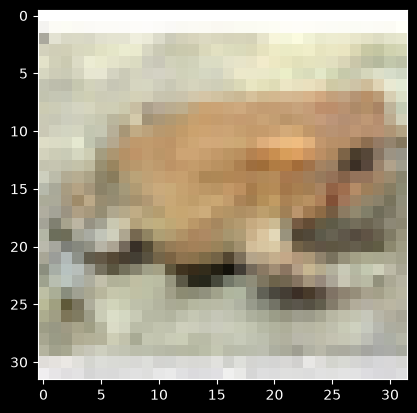

In [6]:
i = 1
print(labels[i])
plt.imshow(images[i])


#### Callback for 75% acc

In [7]:
class StopAtAccuracyCallback(keras.callbacks.Callback):
    """
    Stops training further once accuracy reached 75% :
    We comparing 2 models with different activation functions on how fast they converge to 75% accuracy.
    """
    def on_epoch_end(self, epoch, logs=None):
        accuracy = logs.get('accuracy')
        if accuracy is not None and accuracy >= 0.75:
            print(f"\nReached {accuracy*100:.2f}% accuracy at epoch {epoch+1}, stopping training!")
            self.model.stop_training = True

accuracy_callback = StopAtAccuracyCallback()

#### Model with Tanh

In [8]:
model_tanh = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Conv2D(32, (3, 3), strides=(2, 2), activation='tanh', padding='same'),
        keras.layers.Conv2D(64, (3, 3), strides=(2, 2), activation='tanh', padding='same'),
        keras.layers.Conv2D(128, (3, 3), strides=(2, 2), activation='tanh', padding='same'),
        keras.layers.Conv2D(128, (3, 3), strides=(2, 2), activation='tanh', padding='same'),
        keras.layers.Flatten(),
        keras.layers.Dense(10, "softmax")
    ]
)
model_tanh.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,962 (960.79 KB)

 Trainable params: 245,962 (960.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_tanh.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tanh = model_tanh.fit(train_data, epochs=50, callbacks=[accuracy_callback])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.3800 - loss: 1.7642
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.4577 - loss: 1.5226
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.5146 - loss: 1.3742
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5628 - loss: 1.2275
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5864 - loss: 1.1644
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6079 - loss: 1.1068
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6312 - loss: 1.0430
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6515 - loss: 0.9851
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6728 - loss: 0.9207
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6928 - loss: 0.8614
Epoch 12/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7159 - loss: 0.8001
Epoch 1

#### Model with ReLU

In [27]:
model_relu = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Conv2D(32, (3, 3), strides=(2, 2), activation='relu', padding='same'),
        keras.layers.Conv2D(64, (3, 3), strides=(2, 2), activation='relu', padding='same'),
        keras.layers.Conv2D(128, (3, 3), strides=(2, 2), activation='relu', padding='same'),
        keras.layers.Conv2D(128, (3, 3), strides=(2, 2), activation='relu', padding='same'),
        keras.layers.Flatten(),
        keras.layers.Dense(10, "softmax")
    ]
)
model_relu.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,962 (960.79 KB)

 Trainable params: 245,962 (960.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model_relu.compile(
    optimizer=keras.optimizers.Adam(0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_relu = model_relu.fit(train_data, epochs=50, callbacks=[accuracy_callback])

# Using very slow learning rate coz default 0.001 lr made 75% acghive in single epoch
# model tanh uses adam with 0.001 : achives 75% in 14 epochs
# model relu uses adam with 0.0005 : achives 75% in 7 epochs (75% in 1 poch with same learning rate)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.4279 - loss: 1.5723
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5544 - loss: 1.2493
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6157 - loss: 1.0843
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6602 - loss: 0.9701
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6951 - loss: 0.8753
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7242 - loss: 0.7851
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7523 - loss: 0.7063
Reached 75.23% accuracy at epoch 7, stopping training!
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7523 - loss: 0.7063


#### Comparisions

[]

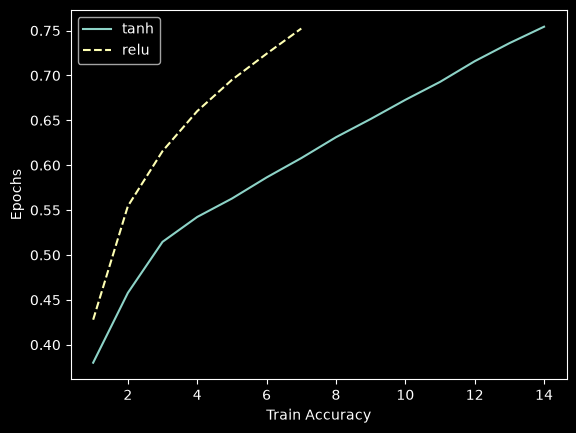

In [29]:
epoch_tanh = list(range(1, len(history_tanh.history["accuracy"])+1))
epoch_relu = list(range(1, len(history_relu.history["accuracy"])+1))
plt.plot(epoch_tanh, history_tanh.history["accuracy"], '-', label="tanh")
plt.plot(epoch_relu, history_relu.history["accuracy"], '--', label="relu")
plt.legend()
plt.ylabel("Train Accuracy")
plt.xlabel("Epochs")
plt.plot()


[]

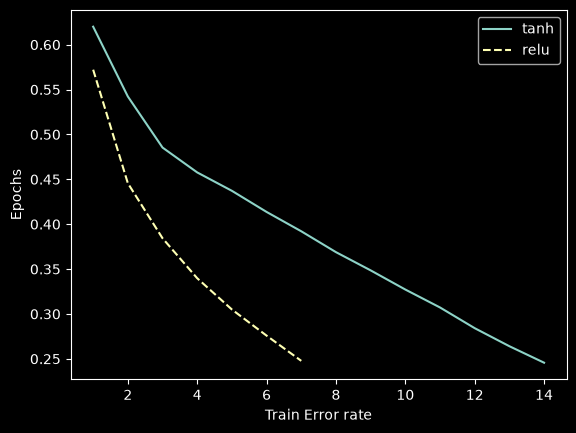

In [36]:
epoch_tanh = list(range(1, len(history_tanh.history["accuracy"])+1))
epoch_relu = list(range(1, len(history_relu.history["accuracy"])+1))
plt.plot(epoch_tanh, 1- np.array(history_tanh.history["accuracy"]), '-', label="tanh")
plt.plot(epoch_relu, 1- np.array(history_relu.history["accuracy"]), '--', label="relu")
plt.legend()
plt.ylabel("Train Error rate")
plt.xlabel("Epochs")
plt.plot()
